In [1]:
from utils import get_match_df, analyze_strategies, get_best_leagues, get_best_strategies

df = get_match_df()

df.head()

AttributeError: 'NoneType' object has no attribute 'group'

## Approccio 1: Scommetto tutti i mercati e tutti i campionati

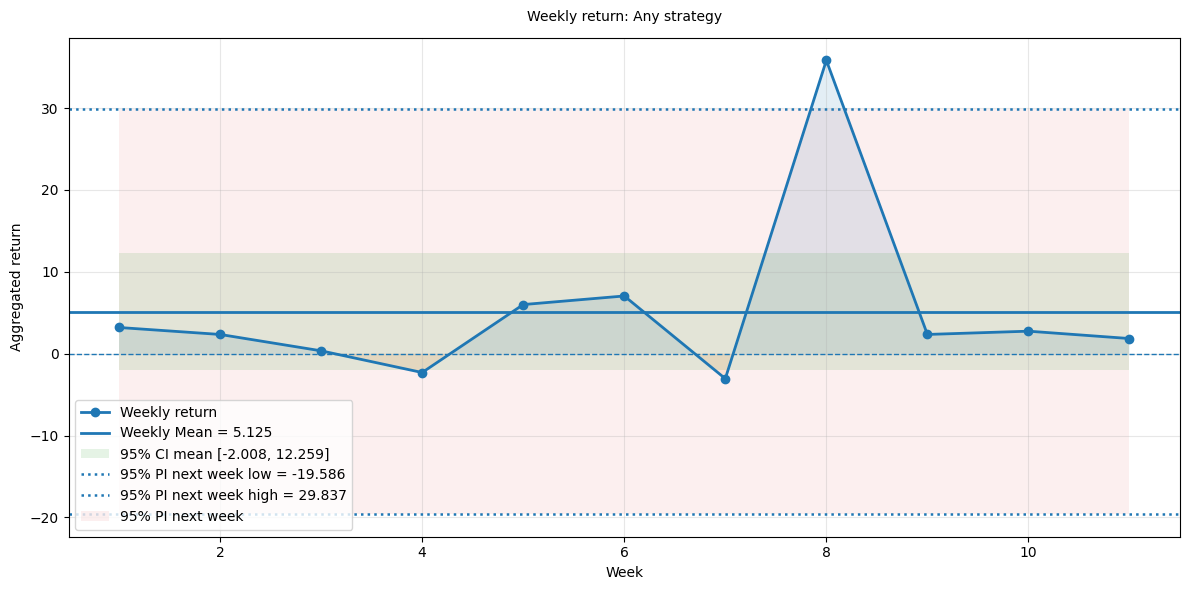

In [19]:
weekly_return, stats = analyze_strategies(df, print_pi=True)

95% PI è la probabilità che il ritorno della prossima settimana sia compreso fra PI low e PI high
### Note:
1. Ritorno medio è positivo ma a estremo inferiore CI negativo -> non è detto che il vero valor medio del ritorno settimanale è > 0
2. 95% PI estremamente variabile

## Approccio 2: scommetto i mercati che si comportano meglio su tutti i campionati

In [5]:
strategy_df = get_best_strategies(df)
strategy_df

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
DNB 1,0.75,2.40,8.27,91,0.74
Over 1.5 (M2-X),0.62,2.03,6.91,76,0.77
Goal HT,0.41,1.81,4.91,54,0.82
Over 0.5 HT (Live),0.36,1.27,4.82,53,0.82
Win x2 HT,0.36,1.70,2.00,22,0.66
CN Home (Asiatic),0.17,1.03,3.00,33,0.59
Multigoal 1-2 Home,0.14,1.24,0.91,10,0.75
Win 1,0.00,0.91,1.91,21,0.70
DNB 2,-0.80,2.33,5.09,56,0.69


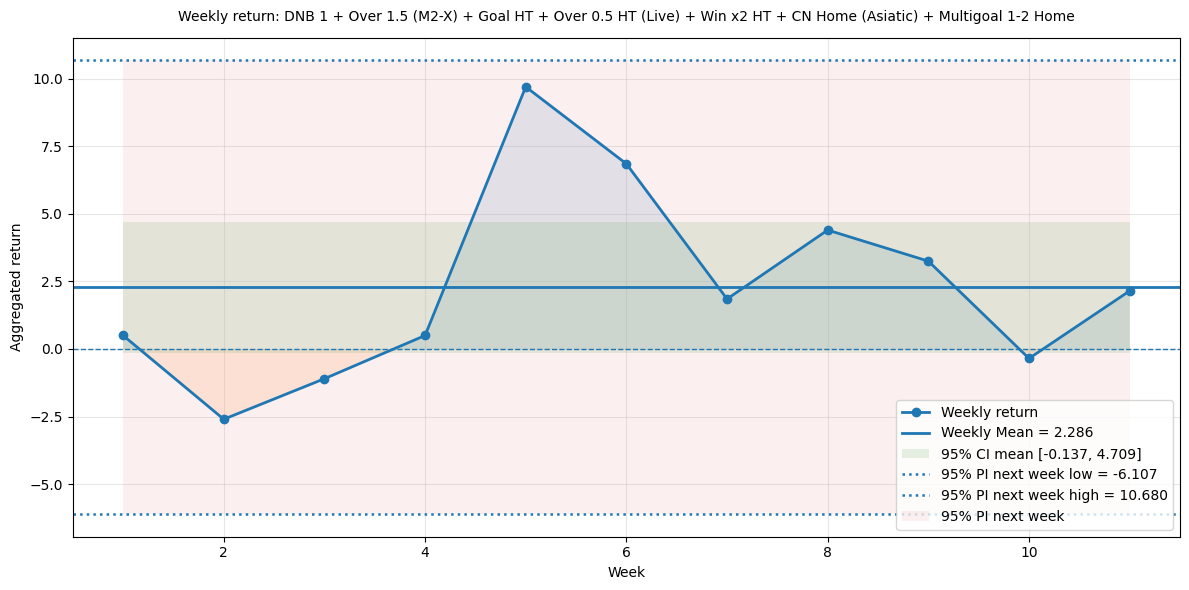

In [6]:
# Tolgo mercati con ritorno medio settimanale negativo e analizzo le strategie
best_strategies = strategy_df[strategy_df["weekly_mean_return"] > 0].index.to_list()
weekly_return, stats = analyze_strategies(df, strategies=best_strategies, print_pi=True)

### Note:
- Valor medio leggermente più alto ma meno confidente (CI mean)
- Intervallo PI maggiore -> più volatile
- Andando a vedere sopra, BTTS è quello che porta più ritorno ma è quello più volatile (ha performato particolarmente bene in week 7), provo a toglierlo

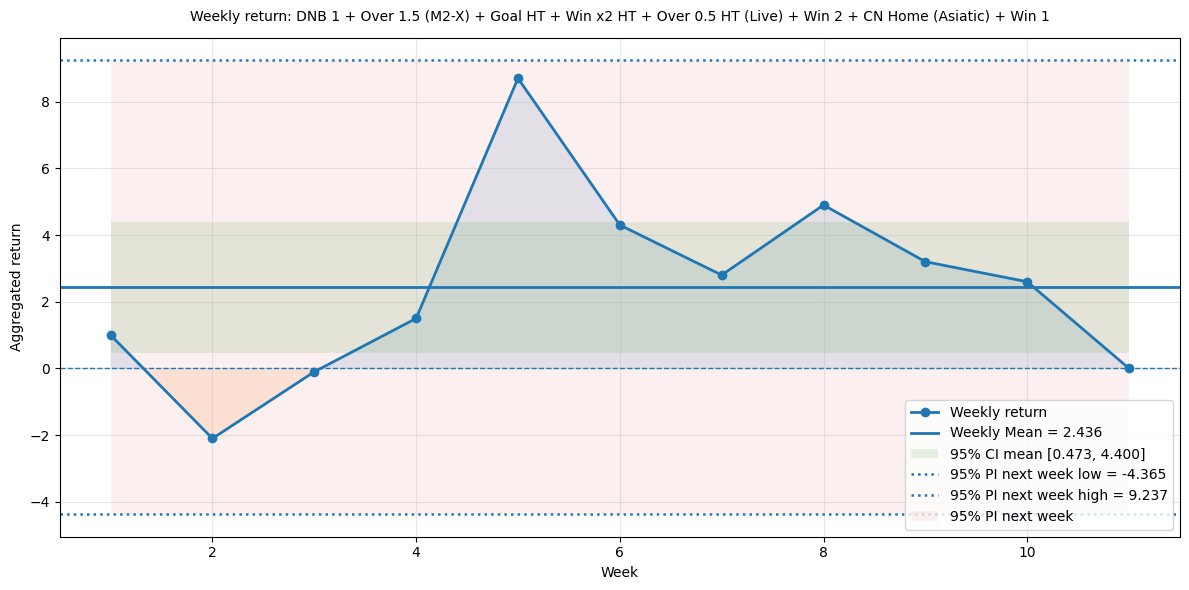

In [7]:
weekly_return, stats = analyze_strategies(df, strategies=['DNB 1', 'Over 1.5 (M2-X)', 'Goal HT', 'Win x2 HT', 'Over 0.5 HT (Live)', 'Win 2', 'CN Home (Asiatic)', 'Win 1'], print_pi=True)

### Note:
- ritorno medio minore ma CI low > 0 -> al 95% il ritorno medio settimanale è positivo
- PI molto meno variabile

## Approccio 3: scommetto solo sui campionati migliori

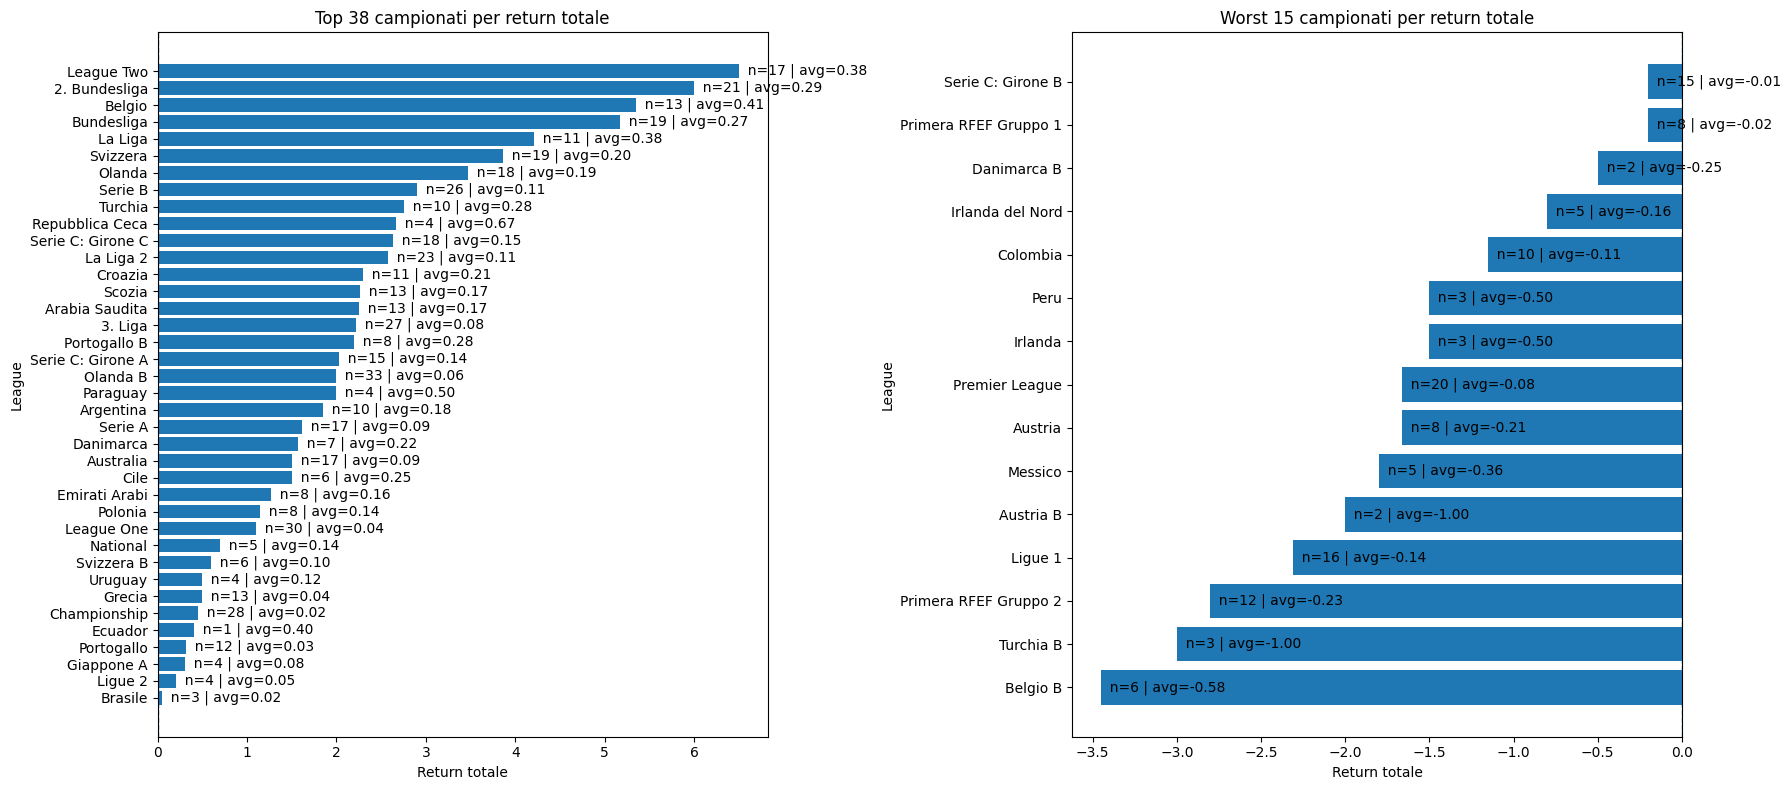

In [8]:
best_leagues = get_best_leagues(df)

In [9]:
# Vedo quali sono le migliori scommesse per i campionati con ritorno positivo (considero solo campionati grafico a sx)
get_best_strategies(df, leagues=list(best_leagues.index))

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
DNB 1,0.99,2.33,6.91,76,0.81
Goal HT,0.82,1.40,4.09,45,0.87
Over 1.5 (M2-X),0.81,1.58,4.45,49,0.84
Win x2 HT,0.80,1.72,1.64,18,0.81
Over 0.5 HT (Live),0.47,0.94,3.91,43,0.85
Multigoal 1-2 Home,0.46,0.94,0.64,7,0.80
DNB 2,0.17,1.17,4.09,45,0.74
Win 1,0.17,0.94,1.36,15,0.76
CN Home (Asiatic),0.00,1.35,2.45,27,0.60


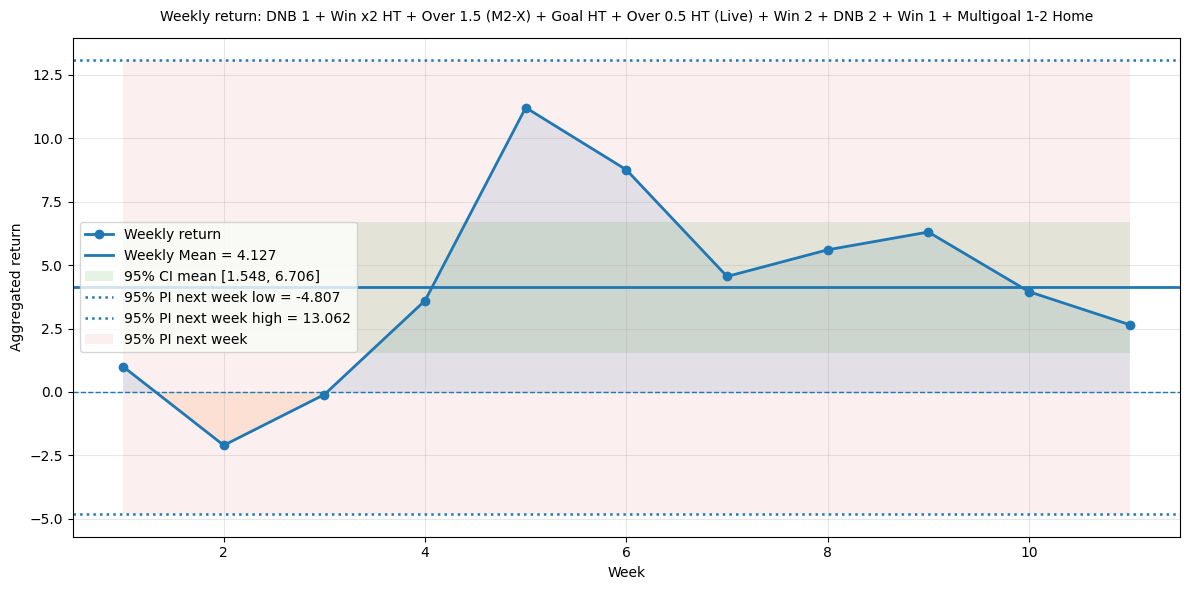

In [10]:
# Prendo le strategie migliori togliendo CN Home perchè ha ritorno negativo e BTTS per alta volatilità
best_strategies = ['DNB 1', 'Win x2 HT', 'Over 1.5 (M2-X)', 'Goal HT',
       'Over 0.5 HT (Live)', 'Win 2', 'DNB 2', 'Win 1', 'Multigoal 1-2 Home']

weekly_return, stats = analyze_strategies(df, strategies=best_strategies, leagues=list(best_leagues.index), print_pi=True)

### Note:
- Ritorno medio più alto del precedente ma ancora minore del primo
- Confidenza molto più alta sia del primo che del secondo (CI low 1.5 vuol dire che il valor medio sul lungo periodo è almeno 1.53 al 95% di confidenza)
- Variabilità sulla settimana (PI) maggiore di prima ma più spostato verso l'alto

In [11]:
set(df['league'].unique())

{'2. Bundesliga',
 '3. Liga',
 'Arabia Saudita',
 'Argentina',
 'Argentina B',
 'Australia',
 'Austria',
 'Austria B',
 'Belgio',
 'Belgio B',
 'Brasile',
 'Bundesliga',
 'Championship',
 'Cile',
 'Colombia',
 'Croazia',
 'Danimarca',
 'Danimarca B',
 'Ecuador',
 'Emirati Arabi',
 'Giappone A',
 'Grecia',
 'Irlanda',
 'Irlanda del Nord',
 'La Liga',
 'La Liga 2',
 'League One',
 'League Two',
 'Ligue 1',
 'Ligue 2',
 'Messico',
 'National',
 'Olanda',
 'Olanda B',
 'Paraguay',
 'Peru',
 'Polonia',
 'Portogallo',
 'Portogallo B',
 'Premier League',
 'Primera RFEF Gruppo 1',
 'Primera RFEF Gruppo 2',
 'Repubblica Ceca',
 'Scozia',
 'Serie A',
 'Serie B',
 'Serie C: Girone A',
 'Serie C: Girone B',
 'Serie C: Girone C',
 'Svizzera',
 'Svizzera B',
 'Turchia',
 'Turchia B',
 'Uruguay'}

In [12]:
set(['League Two',
  '2. Bundesliga',
  'Belgio',
  'Bundesliga',
  'La Liga',
  'Serie B',
  'Olanda B',
  'Svizzera',
  'Olanda',
  'Repubblica Ceca',
  'Serie C: Girone C',
  'La Liga 2',
  'Turchia',
  'Croazia',
  'Scozia',
  'Arabia Saudita',
  '3. Liga',
  'Portogallo B',
  'Serie C: Girone A',
  'Paraguay',
  'Serie A',
  'Danimarca',
  'Australia',
  'Argentina',
  'Polonia',
  'League One',
  'Emirati Arabi',
  'National',
  'Svizzera B',
  'Grecia',
  'Irlanda',
  'Uruguay',
  'Cile',
  'Portogallo',
  'Ligue 2'])

{'2. Bundesliga',
 '3. Liga',
 'Arabia Saudita',
 'Argentina',
 'Australia',
 'Belgio',
 'Bundesliga',
 'Cile',
 'Croazia',
 'Danimarca',
 'Emirati Arabi',
 'Grecia',
 'Irlanda',
 'La Liga',
 'La Liga 2',
 'League One',
 'League Two',
 'Ligue 2',
 'National',
 'Olanda',
 'Olanda B',
 'Paraguay',
 'Polonia',
 'Portogallo',
 'Portogallo B',
 'Repubblica Ceca',
 'Scozia',
 'Serie A',
 'Serie B',
 'Serie C: Girone A',
 'Serie C: Girone C',
 'Svizzera',
 'Svizzera B',
 'Turchia',
 'Uruguay'}

In [28]:
df['return'].unique()

array([-1.  ,  0.5 ,  0.3 ,  0.25,  0.8 ,  0.4 ,  0.55,  0.93,  0.94,
        0.68,  0.7 ])

In [22]:
df[(df['strategy'] == "DNB 1")]

,date,time,league,home_team,away_team,strategy,result,return,week
match_id,,,,,,,,,
d19577439,2026-01-16,11:45,Australia,Perth Glory,Brisbane Roar,DNB 1,False,-1.00,2
d19429865,2026-01-16,20:00,Olanda B,VVV,Venlo - Jong AZ,DNB 1,False,-1.00,2
d19509254,2026-01-16,20:30,Serie B,Sampdoria,Virtus Entella,DNB 1,True,0.30,2
d19439443,2026-01-16,21:00,La Liga,Espanyol,Girona,DNB 1,False,-1.00,2
d19434101,2026-01-17,13:00,2. Bundesliga,Dynamo Dresden,SpVgg Greuther Fürth,DNB 1,True,0.30,2
d19432620,2026-01-17,16:00,League One,Peterborough United,Plymouth Argyle,DNB 1,False,-1.00,2
d19445581,2026-01-18,14:00,Svizzera,Servette,Zürich,DNB 1,True,0.30,2
d19445581,2026-01-19,14:00,Svizzera,Servette,Zürich,DNB 1,True,0.30,3
d19441321,2026-01-23,20:30,La Liga 2,Málaga,Burgos,DNB 1,True,0.30,3
